# Layer 2: Semantic Topic Discovery Audit

This notebook audits the saved BERTopic outputs from `run_layer2.py`. It does not refit BERTopic. It loads the enriched parquet, topic summary, and committed figures to validate the semantic story.


<!-- notebook-rationale -->
## Why this notebook does not refit BERTopic

BERTopic is computationally expensive and belongs in `run_layer2.py`. This notebook audits the saved outputs so reviewers can inspect the semantic results without waiting for embeddings, UMAP, HDBSCAN, and topic reduction to run.

That is also a reproducibility choice. The notebook validates the artifact used in README and slides, rather than creating a new topic model with potentially different cluster assignments.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "outputs" / "data"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
RAW_DIR = PROJECT_ROOT / "data" / "raw"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})


## Load Layer 2 Output

Expected final artifact: `outputs/data/asrs_layer2.parquet`, shape **43,829 x 206**.


<!-- notebook-rationale -->
## What the Layer 2 artifact represents

`asrs_layer2.parquet` is the Layer 1 corpus plus `topic_id` and `topic_label`. Records that are too short or invalid for topic modeling remain in the full corpus with a sentinel topic so downstream row alignment is preserved.

Preserving all 43,829 rows is important because Layer 3 and Layer 4 need consistent incident-level metadata even when a record was not modeled by BERTopic.


In [2]:
layer2_path = DATA_DIR / "asrs_layer2.parquet"
summary_path = DATA_DIR / "layer2_topic_summary.csv"
assert layer2_path.exists(), "Run `uv run python run_layer2.py` first."
assert summary_path.exists(), "Layer 2 topic summary CSV is missing."
asrs = pd.read_parquet(layer2_path)
asrs["date"] = pd.to_datetime(asrs["date"], errors="coerce")
topic_summary = pd.read_csv(summary_path)
print(f"Layer 2 shape: {asrs.shape}")
assert asrs.shape == (43829, 206)
assert {"topic_id", "topic_label"}.issubset(asrs.columns)


Layer 2 shape: (43829, 206)


## Topic Summary

BERTopic reduced 94 natural HDBSCAN clusters to 40 topic IDs, with 39 non-noise topics. Noise is expected in heterogeneous safety text.


<!-- notebook-rationale -->
## Why BERTopic is appropriate here

BERTopic is useful because it discovers narrative themes without predefined labels. That is exactly the problem in early warning: emerging risks may appear in language before they appear in formal categories.

The noise rate is not treated as failure. ASRS narratives are heterogeneous, and HDBSCAN only assigns dense clusters when the documents are semantically coherent enough. Noise documents still remain available to downstream layers; they simply are not used as evidence for a named semantic topic.


In [3]:
display(topic_summary)
noise_count = int((asrs["topic_id"] == -1).sum())
modeled_count = int((asrs["topic_id"] != -2).sum())
print(f"Documents modeled: {modeled_count:,}")
print(f"Noise documents: {noise_count:,}")
assert modeled_count == 42967
assert noise_count == 16376


,Topic,Count,Name,keywords
0,0,3429,0_engine_the_and_we,"engine, the, and, we, to, was, of, at"
1,1,3397,1_the_to_approach_and,"the, to, approach, and, we, was, aircraft, tra..."
2,2,2980,2_gear_the_to_and,"gear, the, to, and, runway, landing, was, on"
3,3,2760,3_runway_aircraft_traffic_on,"runway, aircraft, traffic, on, pattern, the, t..."
4,4,2194,4_smell_smoke_the_odor,"smell, smoke, the, odor, and, to, flight, we"
5,5,1634,5_turbulence_wake_we_the,"turbulence, wake, we, the, and, to, of, were"
6,6,1121,6_maintenance_the_that_and,"maintenance, the, that, and, to, was, mel, of"
7,7,1023,7_brake_the_tug_parking,"brake, the, tug, parking, push, brakes, to, set"
8,8,886,8_door_the_and_to,"door, the, and, to, flight, was, that, passenger"
9,9,807,9_drone_the_was_it,"drone, the, was, it, of, uas, my, airspace"


Documents modeled: 42,967
Noise documents: 16,376


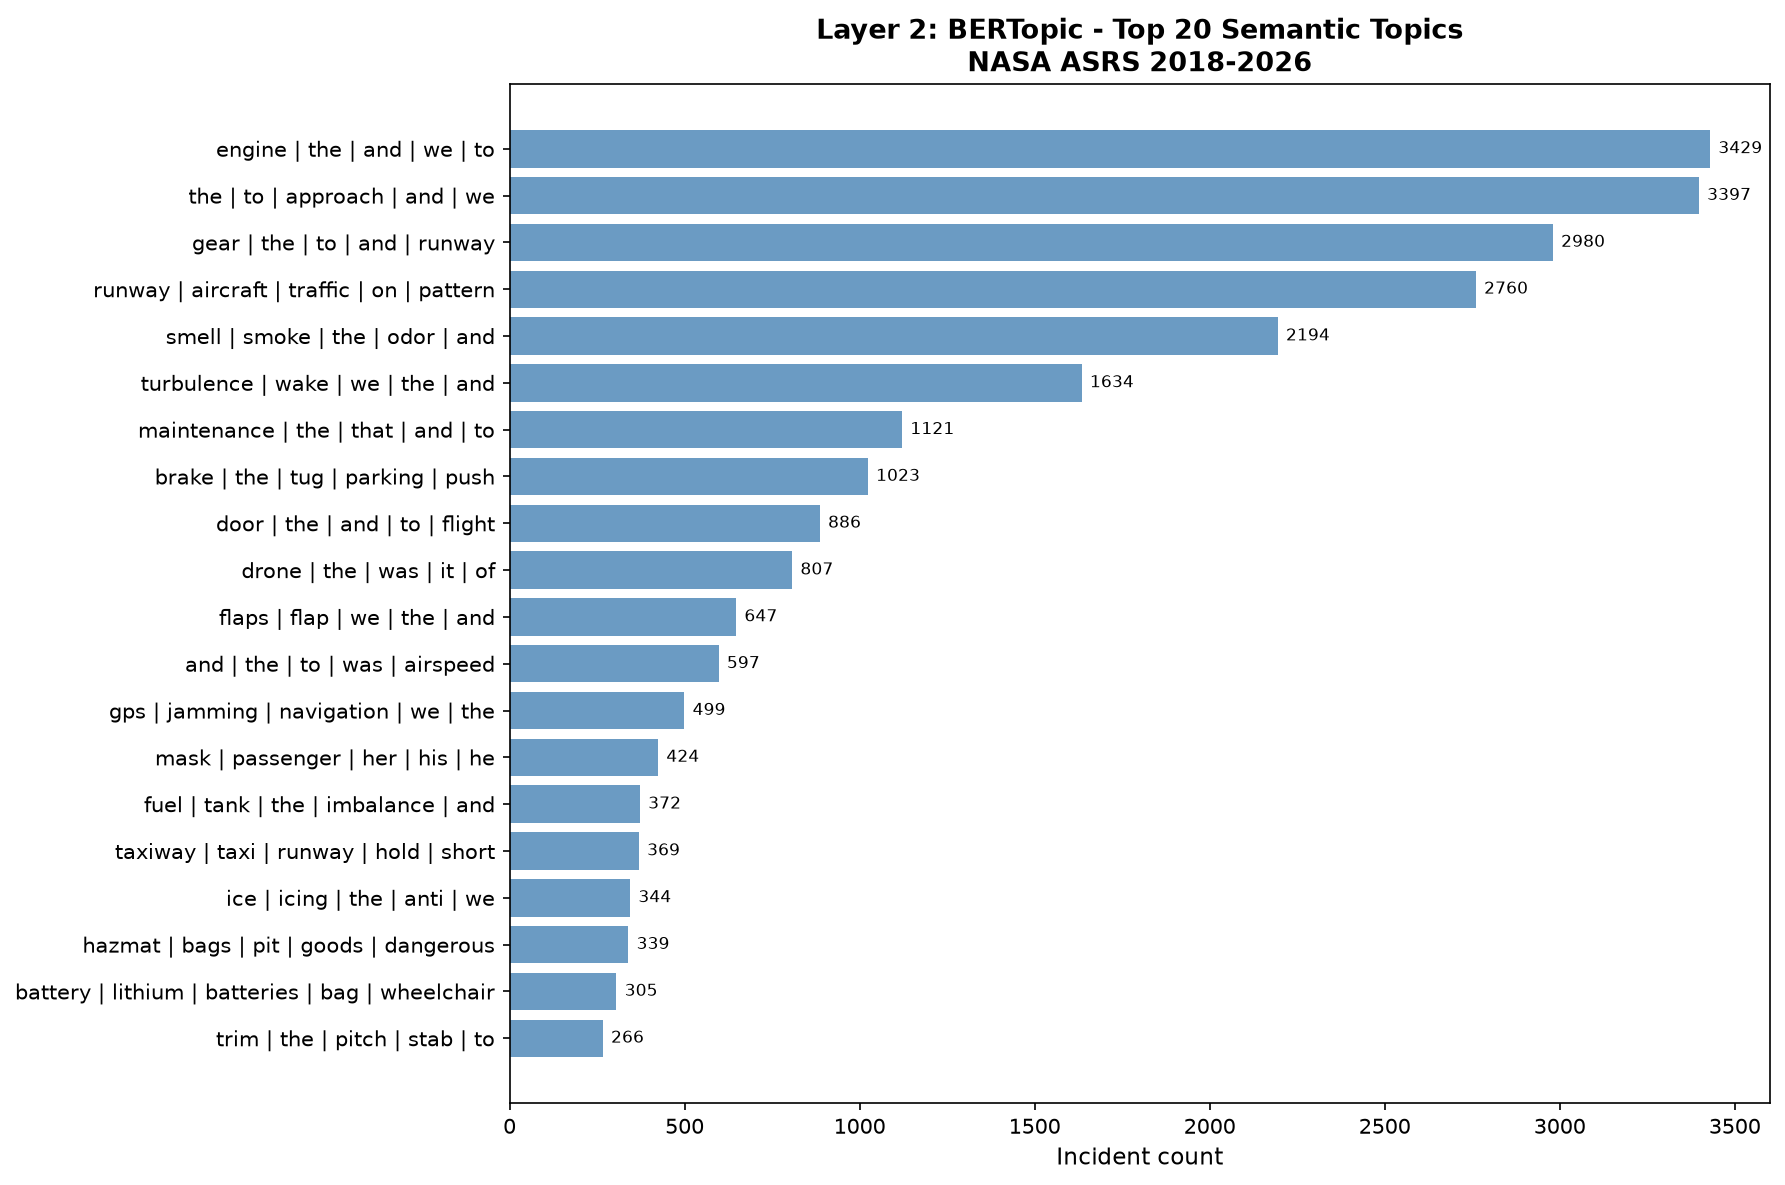

In [4]:
display(Image(filename=str(FIGURES_DIR / "layer2_topic_landscape.png")))


## GNSS / RF Interference Validation

Topic 12 captures GPS/jamming/navigation. Topic 27 captures 5G/altimeter interference as a separate RF topic.


<!-- notebook-rationale -->
## Why topic 12 and topic 27 matter

The central validation is that BERTopic separates GPS/jamming/navigation from 5G/altimeter interference without being told either category exists. That means the GNSS/RF story is not merely a regex artifact from Layer 1; it appears as a coherent semantic structure in the narratives.

Topic 12 supports the GPS/jamming/navigation story. Topic 27 shows that the model can separate a related but operationally different RF interference issue. That separation is important because a safety analyst would not want all radio-frequency concerns merged into one undifferentiated alert.


In [5]:
gnss_topics = [12, 27]
gnss_topic_counts = asrs[asrs["topic_id"].isin(gnss_topics)].groupby(["topic_id", "topic_label"]).size().rename("incidents").reset_index()
display(gnss_topic_counts)
assert int(gnss_topic_counts.loc[gnss_topic_counts["topic_id"] == 12, "incidents"].iloc[0]) == 499
assert int(gnss_topic_counts.loc[gnss_topic_counts["topic_id"] == 27, "incidents"].iloc[0]) == 106
gnss_yearly = asrs[asrs["topic_id"].isin(gnss_topics)].groupby(asrs.loc[asrs["topic_id"].isin(gnss_topics), "date"].dt.year)["ACN"].count().rename("GNSS/RF topic incidents")
display(gnss_yearly.to_frame())


,topic_id,topic_label,incidents
0,12,12_gps_jamming_navigation_we,499
1,27,27_altimeter_setting_5g_the,106


,GNSS/RF topic incidents
date,
2018,27
2019,58
2020,27
2021,43
2022,106
2023,72
2024,138
2025,123
2026,11


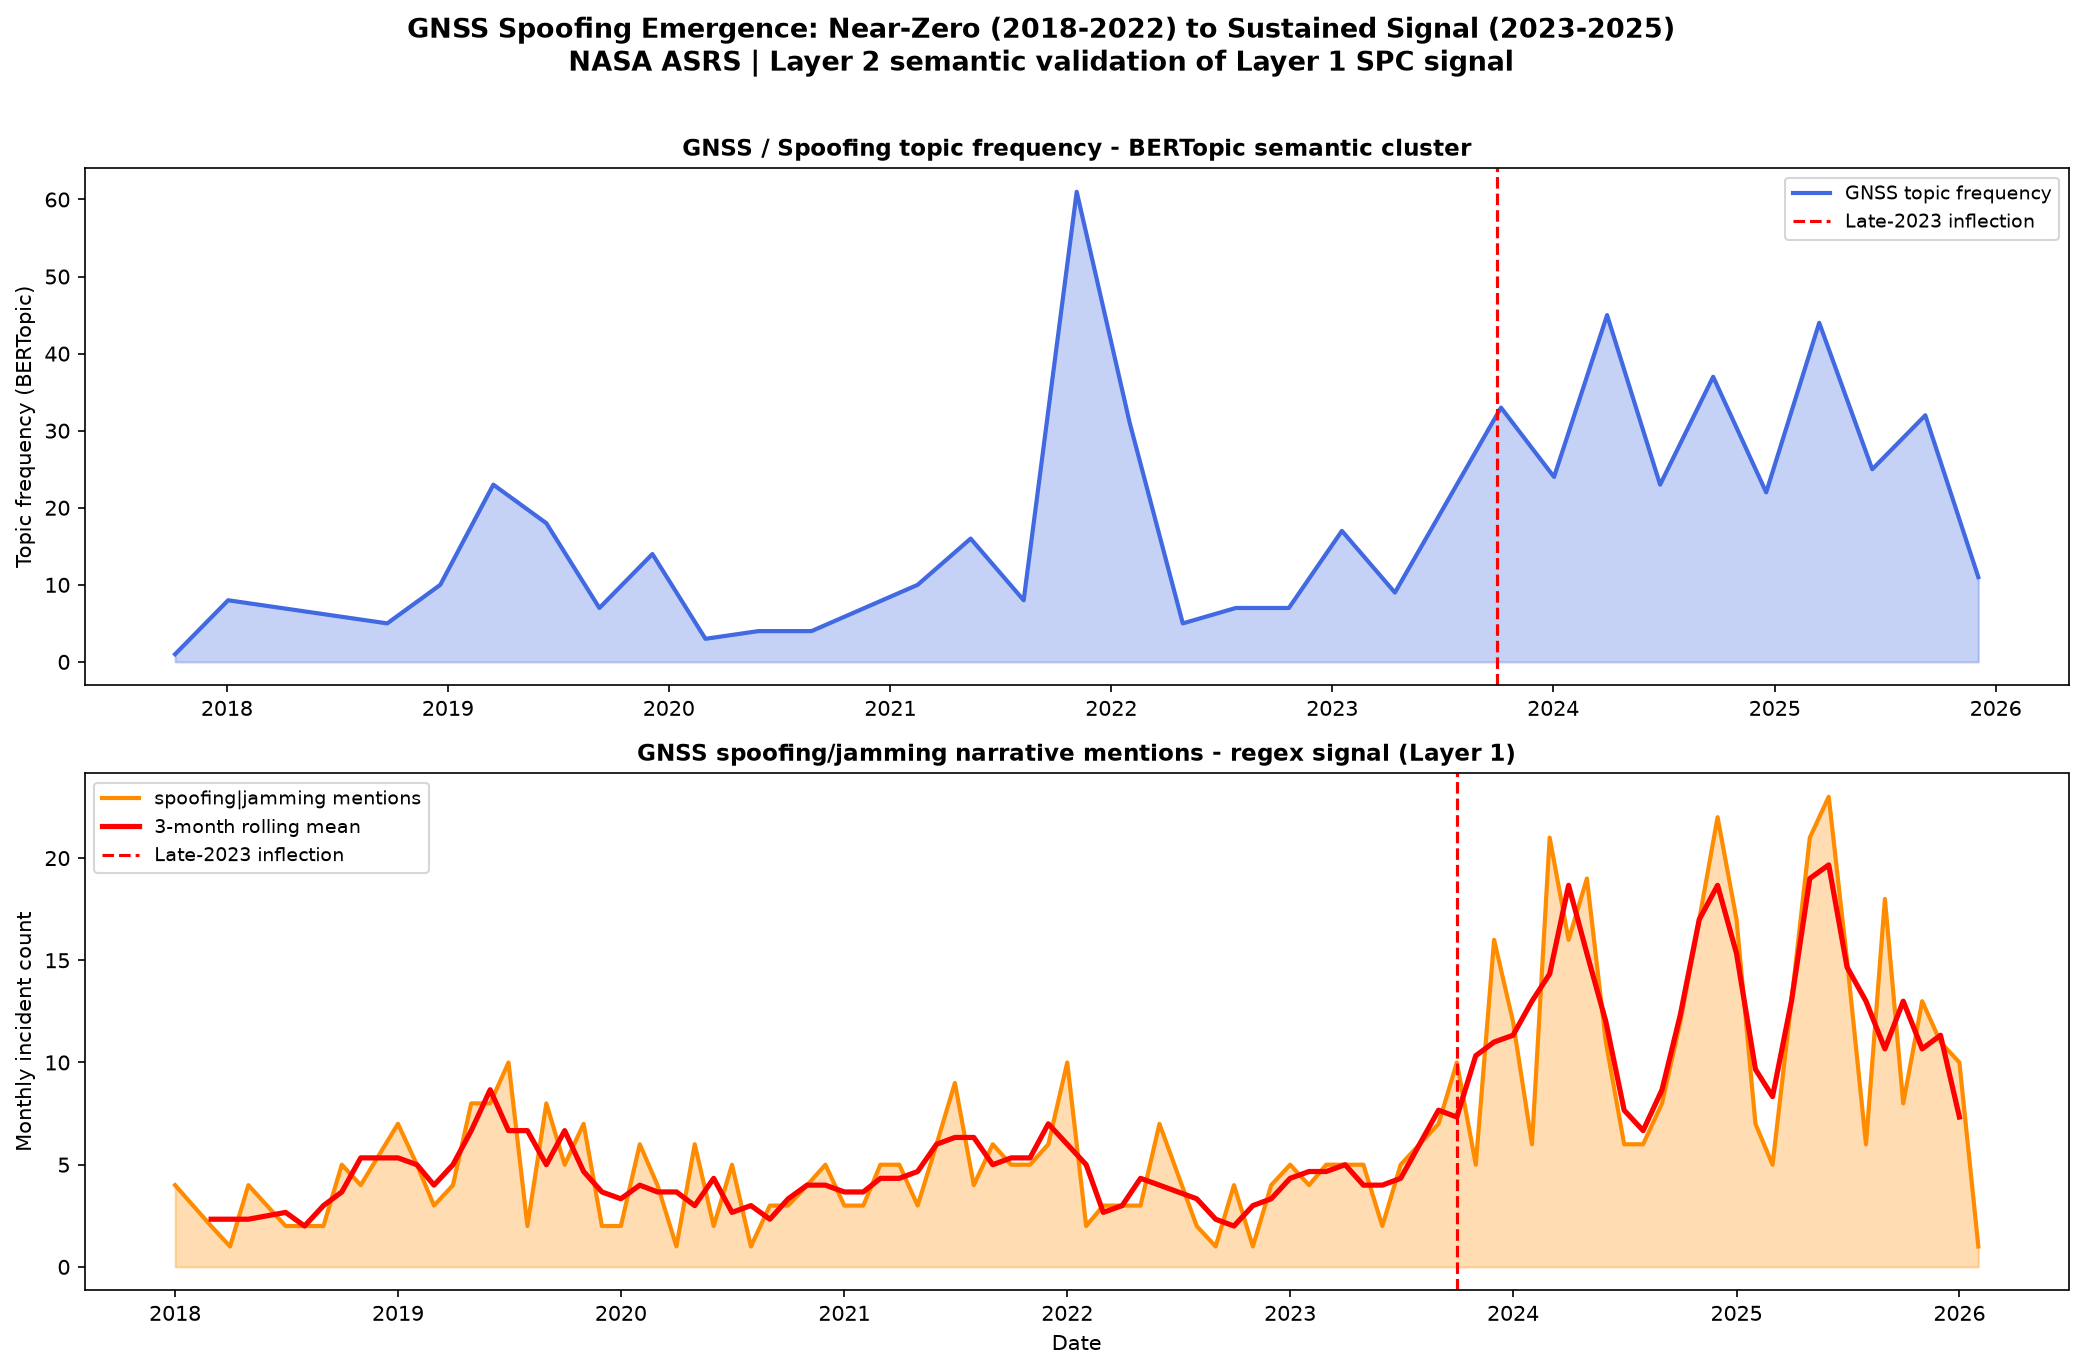

In [6]:
display(Image(filename=str(FIGURES_DIR / "layer2_gnss_emergence.png")))


## Topic Evolution and RED Quadrant Context

These figures support two review questions: which topics are growing over time, and which semantic themes appear within the RED quadrant?


<!-- notebook-rationale -->
## Why the figures are shown instead of recreated

The figures are generated by the pipeline and committed as reviewer-facing artifacts. The notebook displays them to connect the numerical topic audit with the visual evidence used in the presentation.

The heatmap answers a temporal question: which topics are growing, shrinking, or sustained? The RED-topic plot answers a triage question: what semantic themes are present among incidents already prioritized by the Layer 1 quadrant.


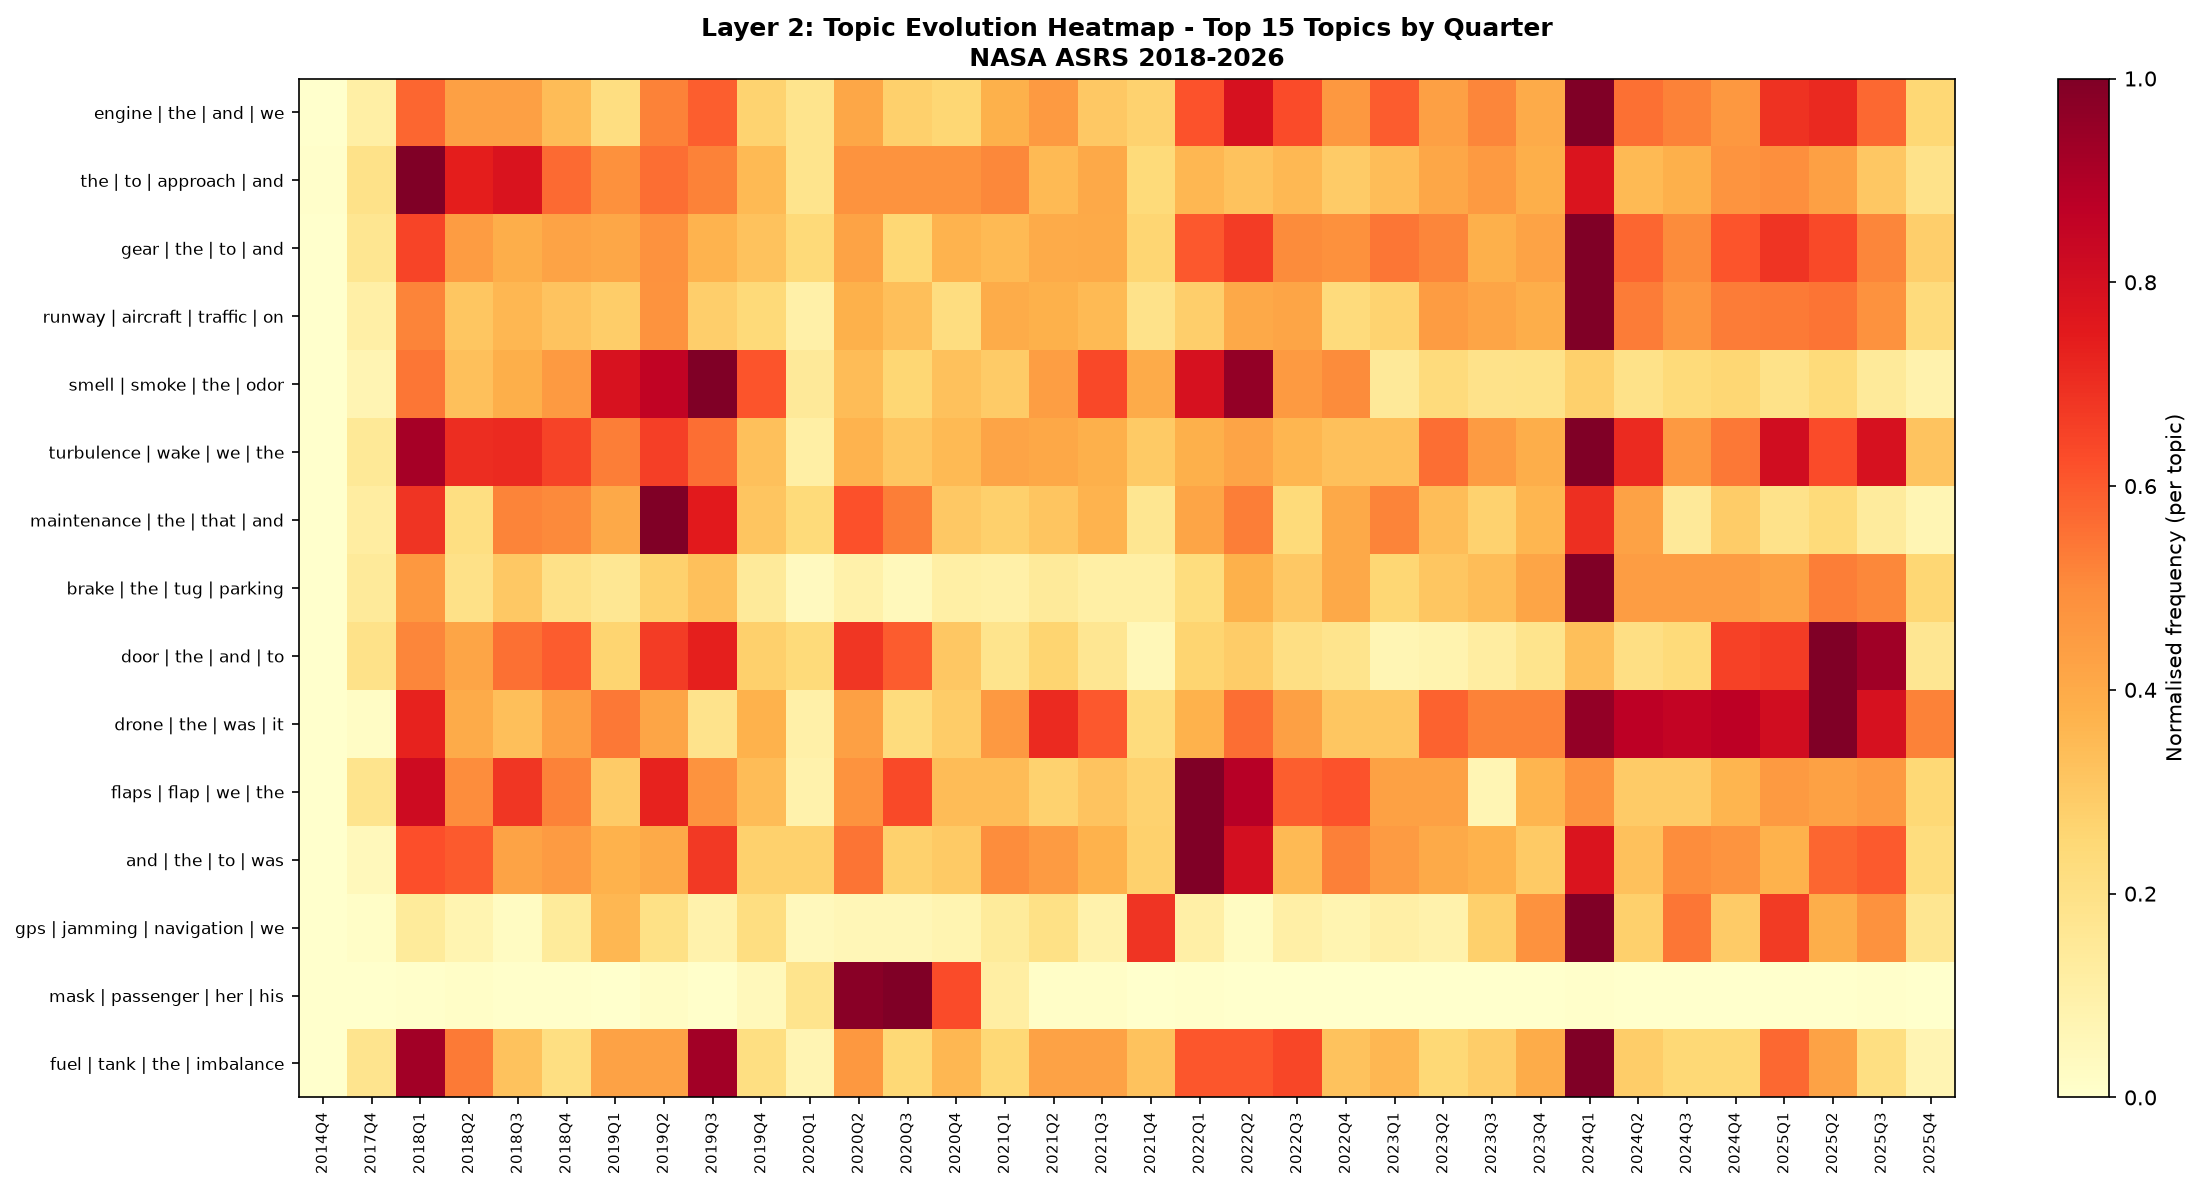

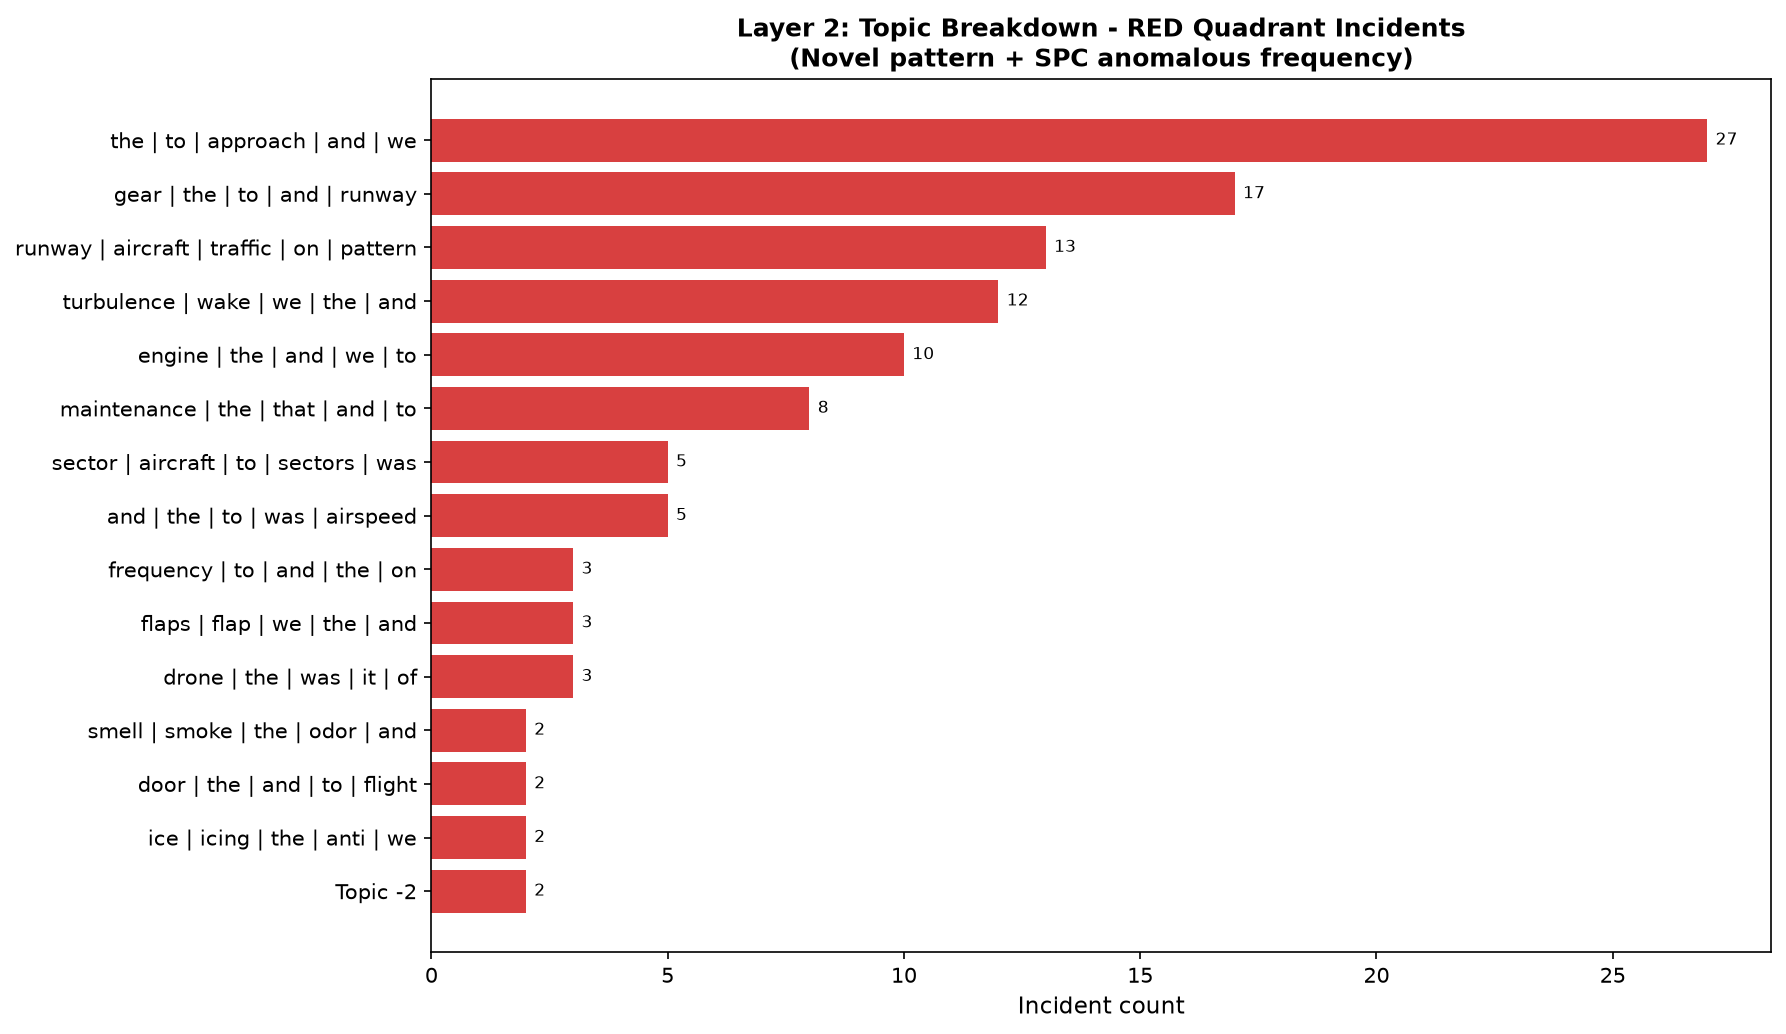

In [7]:
display(Image(filename=str(FIGURES_DIR / "layer2_topic_heatmap.png")))
display(Image(filename=str(FIGURES_DIR / "layer2_red_topics.png")))


## Layer 2 to Layer 3 Handoff

Layer 2 adds `topic_id` and `topic_label`. Layer 3 keeps these columns and adds an auditable human-factors risk score so analysts can prioritize within and across topics.


<!-- notebook-rationale -->
## Why semantic topics are not the final risk score

A topic tells us what an incident is about; it does not by itself say whether the narrative contains fatigue, near-miss, communication breakdown, urgency, or procedural-deviation precursors. Layer 3 adds that human-factors lens while preserving the topic metadata for analyst context.
